
# Artificial Neural Network  (PyTorch)
## Using the pytorch container and include 1 gpu when starting your sessions

**Goal:** a gentle, hands-on intro to neural networks for a broad audience.  
You'll:
- build a tiny feed‑forward network (MLP) in PyTorch,
- change the number of **layers** and **nodes**, and
- **see** the network as a picture, its **loss curve**, and a **decision boundary** on a simple 2‑D dataset.

> This notebook assumes basic Python familiarity—no ML background needed.



## 1) Setup

Run the next cell to import the few libraries we use.  
We only use **numpy**, **matplotlib**, and **torch**. If `ipywidgets` is present, you’ll also get simple sliders.


In [ ]:
#cell 1
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Optional: ipywidgets for simple interactivity
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# Matplotlib settings for clear plots
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')


## 2) What’s a neural network? (1-paragraph mental model)

Think of a neural network as a stack of math layers. Each layer takes numbers in and sends numbers out.
Each connection has a little knob (a **weight**) the computer learns to turn up or down so the output matches
the examples we give it. Learning = adjusting those knobs to reduce error.



## 3) A simple 2‑D dataset

We'll generate two classes of points in 2D so we can **see** what the network learns.  
Pick one of these shapes by setting `DATASET` to `'blobs'`, `'xor'`, or `'rings'`.

Functions like make_blobs, make_xor, and make_rings generate simple points you can see on an XY plot:

Blobs: easy, linearly separable.

XOR: classic “nonlinear” problem.

Rings: needs curved boundaries.


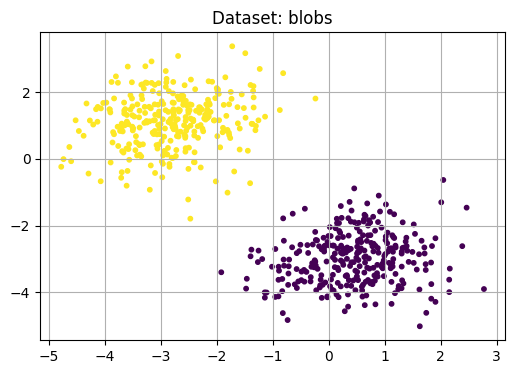

In [ ]:
#cell 2
def make_blobs(n=400, centers=2, spread=0.8, seed=0):
    rng = np.random.default_rng(seed)
    angles = rng.uniform(0, 2*np.pi, size=centers)
    centers_xy = np.stack([np.cos(angles), np.sin(angles)], axis=1) * 3.0
    X = []
    y = []
    for c in range(centers):
        pts = centers_xy[c] + rng.normal(scale=spread, size=(n//centers, 2))
        X.append(pts); y.append(np.full(len(pts), c))
    return np.vstack(X).astype(np.float32), np.concatenate(y).astype(np.int64)

def make_xor(n=400, spread=0.6, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, 2)).astype(np.float32)
    X *= spread
    X += rng.choice([-1, 1], size=(n, 2))  # push into quadrants
    y = ((X[:,0] > 0) ^ (X[:,1] > 0)).astype(np.int64)
    return X, y

def make_rings(n=400, seed=0):
    rng = np.random.default_rng(seed)
    n1, n2 = n//2, n - n//2
    r1 = 2.0 + 0.15 * rng.normal(size=n1)
    r2 = 3.7 + 0.15 * rng.normal(size=n2)
    t1 = rng.uniform(0, 2*np.pi, size=n1)
    t2 = rng.uniform(0, 2*np.pi, size=n2)
    X1 = np.stack([r1*np.cos(t1), r1*np.sin(t1)], axis=1)
    X2 = np.stack([r2*np.cos(t2), r2*np.sin(t2)], axis=1)
    X = np.vstack([X1, X2]).astype(np.float32)
    y = np.concatenate([np.zeros(n1, dtype=np.int64), np.ones(n2, dtype=np.int64)])
    return X, y

DATASET = 'blobs'  # 'blobs', 'xor', or 'rings' - changes nonlinearity of classification decision boundary - TODO try different types

gen = {'blobs': make_blobs, 'xor': make_xor, 'rings': make_rings}[DATASET]
X_np, y_np = gen(n=600, seed=42)
X = torch.from_numpy(X_np)
y = torch.from_numpy(y_np)

fig, ax = plt.subplots()
ax.scatter(X_np[:,0], X_np[:,1], c=y_np, s=10)
ax.set_title(f"Dataset: {DATASET}")
plt.show()


## Review dataset
Lets take a look at the data we will use to predict two predictors: x1, x2  predicting the class label (0 or 1)

In [ ]:
#cell 3
# Show a few data samples numerically before plotting
import pandas as pd

# Combine X and y into one DataFrame for readability
df = pd.DataFrame(X_np, columns=["x1", "x2"])
df["label"] = y_np

print("✅ Here’s what the data looks like (first 10 rows):")
display(df.head(10))

print(df.info()) #600 rows


✅ Here’s what the data looks like (first 10 rows):


,x1,x2,label
0,1.050219,-2.213628,0
1,-1.110970,-4.007823,0
2,0.552130,-3.219074,0
3,0.436417,-3.648515,0
4,1.153376,-2.343846,0
5,0.502682,-2.064287,0
6,0.823865,-3.653513,0
7,0.744858,-3.733186,0
8,1.152618,-3.006020,0
9,0.301968,-3.510823,0


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      600 non-null    float32
 1   x2      600 non-null    float32
 2   label   600 non-null    int64  
dtypes: float32(2), int64(1)
memory usage: 9.5 KB
None



## 4) Build a tiny network

We’ll create a function that builds a **feed‑forward** net (also called an MLP).  
You choose a list like `[8, 8]` for two hidden layers with 8 nodes each (try `[4]`, `[16,16]`, `[32,16,8]`, etc.).


In [ ]:
#cell 4
#this is the constructor we use below to inherit from the nn.module - It gives your model the machinery to register layers and automatically track their parameters (weights, biases).
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, output_dim=2, activation='relu'):
        super().__init__()
        sizes = [input_dim] + list(hidden_sizes) + [output_dim] #creates list of all layer sizes e.g., [2 input, 8 hidden, 8 hidden, 2 output]
        layers = []
        for i in range(len(sizes)-2):  #constructs the hidden layers dynamically from the sizes list and appends selected activation function
            layers.append(nn.Linear(sizes[i], sizes[i+1])) # For [2, 8, 8, 2], len(sizes) = 4, so range(2) means i = 0 and i = 1.
            if activation == 'relu':  #no negatives, negative become 0 and positive unchanged
                layers.append(nn.ReLU())
            elif activation == 'tanh': #outputs smoothly between -1 and +1
                layers.append(nn.Tanh())
            else:
                layers.append(nn.ReLU())
        layers.append(nn.Linear(sizes[-2], sizes[-1])) #-2 second to last element (last hiden layer), -1 is last element the output layer
        self.net = nn.Sequential(*layers) #*unpacks each element of the list into sepeate argument

    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

hidden_sizes = [8, 8]  # change me [8, 8] is two layers with 8 hidden nodes each (more nodes and layers = more variance or flexibility)
activation = 'relu'    # 'relu' or 'tanh'

model = MLP(2, hidden_sizes, 2, activation=activation).to(device)
count_params(model)



## 5) Visualize the network

The next cell draws a simple diagram of the layers and their connections.  
(Every node in a layer connects to every node in the next layer.)


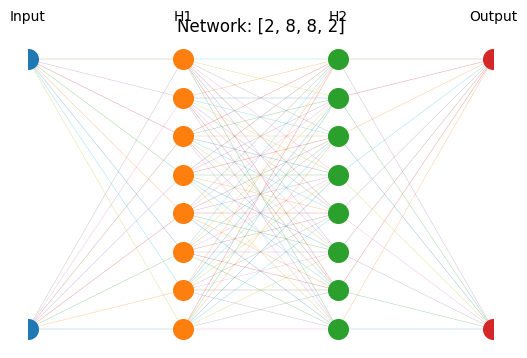

In [ ]:
#cell 5
def draw_network(layer_sizes, ax=None):
    # layer_sizes includes input & output, e.g. [2, 8, 8, 2]
    L = len(layer_sizes)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_xlim(0, L-1)
    max_nodes = max(layer_sizes)
    ax.set_ylim(-0.5, max_nodes-0.5)
    ax.axis('off')

    # Plot nodes
    for i, n_nodes in enumerate(layer_sizes):
        y_positions = np.linspace(0, max_nodes-1, n_nodes)
        ax.scatter(np.full(n_nodes, i), y_positions, s=200, zorder=3)
        # Label layers
        if i == 0:
            ax.text(i, max_nodes, "Input", ha='center')
        elif i == L-1:
            ax.text(i, max_nodes, "Output", ha='center')
        else:
            ax.text(i, max_nodes, f"H{i}", ha='center')

    # Plot edges (fully connected)
    for i in range(L-1):
        n1, n2 = layer_sizes[i], layer_sizes[i+1]
        y1 = np.linspace(0, max_nodes-1, n1)
        y2 = np.linspace(0, max_nodes-1, n2)
        for a in y1:
            for b in y2:
                ax.plot([i, i+1], [a, b], linewidth=0.3, alpha=0.5, zorder=1)

layer_sizes = [2] + hidden_sizes + [2]
draw_network(layer_sizes)
plt.title(f"Network: {layer_sizes}")
plt.show()



## 6) Train it

We’ll split the data into train/validation, run for a small number of epochs,
and plot the **loss** as the network learns.

Feeding the model small chunks of data (“batches”),

Letting it make guesses,

Measuring how wrong it was (loss),

Adjusting its internal weights slightly to improve next time.

This repeats over many epochs (passes through the dataset) until the network learns good parameters.

##Our traing funciton **Parameters:**

model: our neural network (MLP)

X: input features (2D points)

y: target labels (class 0 or 1)

epochs: how many times to loop over the full dataset

lr: learning rate — how big the step updates should be

batch_size: how many examples to process at once before updating weights

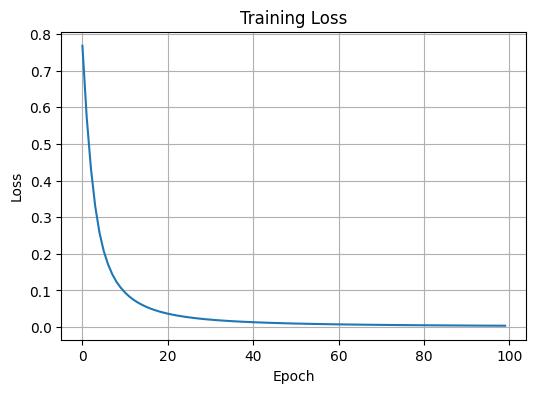

In [ ]:
#cell 6
#define a treaining function to apply the model to
def train_tiny(model, X, y, epochs=100, lr=0.05, batch_size=64):
    ds = TensorDataset(X, y) # wraps predictors and labels tensors to keep predictors and correct labels together when entering the model
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True) #can't submit whole dataset at a time so will chunk data into batch that entered into the model, randomly shuffles every epoch
    opt = torch.optim.SGD(model.parameters(), lr=lr) #the calculus connection, Sotchastic Gradient Descent to identify which weights to update on the backwardpass
    loss_fn = nn.CrossEntropyLoss()  #the loss function It compares the model’s output (logits) to the true label and gives a single “how wrong was I?” number - goal minimize this function

    losses = [] #keep track of loss (error) for each epoch
    model.train() #sets model into training mode
    for epoch in range(epochs):  ##training loop every epoch is one training generation feeding the entire dataset in batches, outerloop
        total = 0.0
        for xb, yb in dl: #inner loop for each batch in the dataset (64 rows at a time untill we get through all 600 rows)
            xb, yb = xb.to(device), yb.to(device) #using dataloader object we extract the current batch looping through all 600 rows by 64 at a time
            opt.zero_grad() #reset the gradeints from the previous batch (
            logits = model(xb) #we send input and labels into model, logits = raw output predictions before softmax (2 numbers per sample, one per class).
            loss = loss_fn(logits, yb) #calculate error compares preeicted logit versus actual, one error value per batch
            loss.backward() #compute gradients for every weight using auto differentiation, backward phase fro mslides propogating error
            opt.step() #update the weights based on the learning rate (higher rate higher change in direction to reduce error or loss function)
            total += loss.item()*len(xb) #tracking average loss weighted by batch size
        losses.append(total/len(ds)) #calculate aerage loss for the ephoc
    return losses #returns losses so we can graph

def plot_losses(losses):
    plt.figure()
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

losses = train_tiny(model, X, y, epochs=100, lr=0.05, batch_size=64)
plot_losses(losses)



## 7) See what it learned (decision boundary)

Below we color the 2‑D plane by the class the network predicts.
A logit is the raw output of the neural network before any squashing or probability conversion.

You can think of it as:

“How confident the neuron is that this input belongs to each class — but on an unscaled, real-number line.”

### Its not in the correct form to use for prediction but the larger the logit the more likely the model believes that class is the correct class

### We usually apply a softmax step at the end to convert into probabilities.
This turns logits (any real numbers) into probabilities that add up to 1.
But during training we don’t do that explicitly, because nn.CrossEntropyLoss() does it automatically inside.

So in this notebook:

During training: we feed logits into the loss (no softmax needed).

During visualization: we take logits and pick the class with the highest value using .argmax().


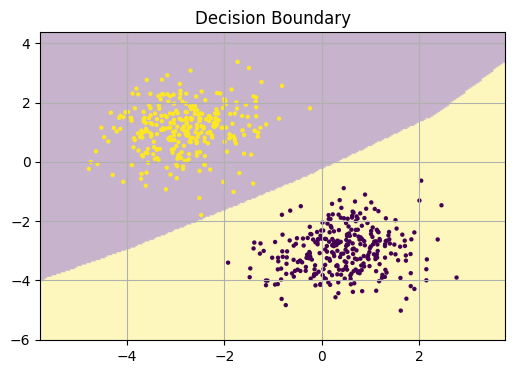

In [ ]:
#cell 7
@torch.no_grad() #we aren't training so we don't want to calculate gradients
def plot_decision_boundary(model, X_np, y_np, steps=200, padding=1.0):
    x_min, x_max = X_np[:,0].min()-padding, X_np[:,0].max()+padding #we define the grid area finds min and max of dataset and pads around the edge
    y_min, y_max = X_np[:,1].min()-padding, X_np[:,1].max()+padding
    xs = np.linspace(x_min, x_max, steps)
    ys = np.linspace(y_min, y_max, steps)
    grid = np.stack(np.meshgrid(xs, ys), axis=-1).reshape(-1, 2).astype(np.float32) #grid is a list of x,y positions one for every pixel in the plot
    logits = model(torch.from_numpy(grid).to(device)).cpu().numpy() #we run the model to predict logits for every x,y combination in the grid running on the GPU
    Z = logits.argmax(axis=1).reshape(steps, steps) #from the results we pick the largest logit value from the pair (argmax) and reshape it to match the 2d grid on the xy positions

    fig, ax = plt.subplots() #we plot the results the colors meet when the logits are equal (kind of like the 50% probability position)
    ax.imshow(Z.T, origin='lower', extent=(x_min, x_max, y_min, y_max), alpha=0.3, aspect='auto')
    ax.scatter(X_np[:,0], X_np[:,1], c=y_np, s=10, edgecolors='none')
    ax.set_title("Decision Boundary")
    plt.show()

model.eval() #tell the model to run in inference or eval mode not training
plot_decision_boundary(model, X_np, y_np)



## 8) Try different layer/node counts

Change `hidden_sizes` above (for example to `[4]`, `[16, 16]`, `[32, 16, 8]`), re‑run:
1. the **Build a tiny network** cell,
2. **Visualize the network** cell,
3. **Train it**cell, and
4. **See what it learned** cell.

> Watch how capacity affects the decision boundary and loss curve.



## 9) (Optional) Interactive controls

If `ipywidgets` is installed, run the cell below for simple sliders to tweak:
- number of hidden layers (0–3),
- nodes per hidden layer (2–64),
- activation (`relu` or `tanh`),
- learning rate, and epochs.

If it errors, skip this section—everything above works without widgets.

#We combine everyting from above into a interactive widget to experiment with different settings

In [ ]:
#cell 8
if HAS_WIDGETS:
    layers_slider = widgets.IntSlider(value=2, min=0, max=3, step=1, description='Hidden layers')
    nodes_slider  = widgets.IntSlider(value=8, min=2, max=64, step=2, description='Nodes/layer')
    act_dropdown  = widgets.Dropdown(options=['relu','tanh'], value='relu', description='Activation')
    lr_float      = widgets.FloatLogSlider(value=0.05, base=10, min=-3, max=0, step=0.1, description='LR')
    epochs_int    = widgets.IntSlider(value=100, min=20, max=400, step=10, description='Epochs')

    out = widgets.Output()

    def run_and_plot(_=None):
        with out:
            clear_output(wait=True)
            hs = [nodes_slider.value]*layers_slider.value
            m = MLP(2, hs, 2, activation=act_dropdown.value).to(device)
            losses = train_tiny(m, X, y, epochs=epochs_int.value, lr=lr_float.value, batch_size=64)
            fig, axes = plt.subplots(1, 2, figsize=(10,4))
            # draw network
            ax = axes[0]
            draw_network([2]+hs+[2], ax=ax)
            ax.set_title(f"Network: {[2]+hs+[2]}")
            # loss
            ax2 = axes[1]
            ax2.plot(losses)
            ax2.set_title("Loss")
            ax2.set_xlabel("Epoch")
            ax2.set_ylabel("Loss")
            plt.show()
            # decision boundary
            m.eval()
            plot_decision_boundary(m, X_np, y_np)

    ui = widgets.VBox([layers_slider, nodes_slider, act_dropdown, lr_float, epochs_int])
    btn = widgets.Button(description="Train & Visualize", button_style='')
    btn.on_click(run_and_plot)

    display(ui, btn, out)
else:
    print("ipywidgets not found. No problem—use the earlier cells to change the architecture and retrain.")


Button(description='Train & Visualize', style=ButtonStyle())

Output()


## 10) (Optional) Saving and loading your model


In [ ]:
#cell 9
# Save
torch.save(model.state_dict(), "tiny_mlp.pt")

# Load later
loaded = MLP(2, hidden_sizes, 2, activation=activation)
loaded.load_state_dict(torch.load("tiny_mlp.pt", map_location='cpu'))
print("Reloaded OK")


Reloaded OK


# ## 11) What’s happening under the hood? (1‑minute version)

- **Activation functions** (we used ReLU/Tanh) let layers stack and model curves instead of straight lines.  
- **Loss** measures “how wrong” we are; training **nudges weights** to reduce it (gradient descent + backprop).  
- **Overfitting** happens when a network gets too wiggly and memorizes noise. Use validation sets or keep the model small.

Try comparing `[4]` vs `[64, 64]` and notice stability, speed, and how smooth or jagged the boundary is.


## 12) Homework Assignment 2 Questions (Total: 100 points)

---

### 1. Dataset–Architecture Analysis (18 points)

For all parts below, only modify parameters that already exist in the provided code
(e.g., `DATASET`, `hidden_sizes`, number of layers).

**1.1** Keep `DATASET = 'blobs'` and experiment with at least two different network architectures  
(vary the number of hidden layers and hidden units).  
Which architecture performs best based on training loss and decision boundary visualization? (5 pts)

**1.2** Change `DATASET = 'xor'` and repeat the experiment with at least two architectures.  
Which architecture performs best? (5 pts)

**1.3** Change `DATASET = 'rings'` and repeat the experiment with at least two architectures.  
Which architecture performs best? (5 pts)

**1.4** Compare the three datasets (`blobs`, `xor`, `rings`).  
How does the decision boundary shape differ across datasets?  
Why do some datasets require deeper or wider networks?  
Support your answer using only observations from your experiments. (3 pts)

---

### 2. Activation Function Comparison (18 points)

Modify only the `activation` argument in the provided model.

**2.1** Train the model using `'relu'` and `'tanh'`.  
Compare the loss curves (convergence speed and stability). (6 pts)

**2.2** Compare the decision boundaries produced by ReLU and Tanh.  
How does the boundary shape visually differ? (6 pts)

**2.3** Based on what you observe in the plots and loss curves,  
explain why the activation function affects training behavior and boundary smoothness. (6 pts)

---

### 3. Learning Rate and Epoch Interaction (18 points)

Modify only `epochs` and `learning_rate`.

**3.1** Increase training epochs to **300** using the original learning rate.  
Describe the behavior of the loss curve. (6 pts)

**3.2** Reduce the learning rate and retrain for 300 epochs.  
How does convergence behavior change? (6 pts)

**3.3** From your observations of the loss curves, explain the relationship between  
learning rate and number of epochs in gradient-based optimization. (6 pts)

---

### 4. Linear Model Test (No Hidden Layers) (18 points)

Modify only `hidden_sizes`.

**4.1** Set `hidden_sizes = []` (no hidden layers) and train the model. (5 pts)

**4.2** Visualize the decision boundary for each dataset (`blobs`, `xor`, `rings`).  
Which dataset(s) can be classified successfully? (7 pts)

**4.3** What does the decision boundary look like in this case?  
Why does this happen? Support your explanation using what you observe from the plots. (6 pts)

---

### 5. Model Capacity and Overfitting Investigation (18 points)

Increase model complexity by significantly increasing hidden units or layers.

**5.1** Describe how the training loss changes as model size increases. (6 pts)

**5.2** How does the decision boundary change compared to smaller models?  
Does it appear smoother, more complex, or irregular? (6 pts)

**5.3** Based only on your experimental observations, explain how increasing model capacity  
affects model behavior and potential overfitting. (6 pts)

---